# [Active Agent Router (저수준 API 방식)](https://reference.langchain.com/python/langgraph/swarm/#langgraph_swarm.swarm.add_active_agent_router)


## Swarm Agents vs Active Agent Router
- Swarm Agents: `create_swarm` 사용 (고수준 API, 간편함)
- Active Agent Router: `StateGraph` + `add_active_agent_router` 사용 (저수준 API, 세밀한 제어)


### 고수준 API (High-level API)
> “자주 쓰이는 패턴을 미리 추상화해서, 최소한의 코드로 바로 쓰게 해주는 API”

`create_swarm` 같은 함수는 멀티 에이전트 협업이라는 복잡한 구조를 한 번에 캡슐화해 둔 API입니다.

| 항목     | 설명         |
| ------ | ---------- |
| 추상화 수준 | 매우 높음      |
| 코드량    | 적음         |
| 진입 장벽  | 낮음         |
| 커스터마이징 | 제한적        |
| 내부 구조  | 대부분 숨겨져 있음 |


### 저수준 API (Low-level API)
> “시스템을 이루는 최소 단위들을 직접 조립해서 원하는 동작을 만들게 해주는 API”

`StateGraph` + `add_active_agent_router`는 멀티에이전트 시스템의 내부 메커니즘을 그대로 노출합니다.

| 항목     | 설명      |
| ------ | ------- |
| 추상화 수준 | 낮음      |
| 코드량    | 많음      |
| 진입 장벽  | 높음      |
| 커스터마이징 | 매우 높음   |
| 내부 구조  | 완전히 드러남 |


### 두 API의 본질적 차이 (핵심 요약)
> 차이는 “기능”이 아니라 “책임의 위치”에 있음

| 구분          | 고수준 API (`create_swarm`) | 저수준 API (`StateGraph`) |
| ----------- | ------------------------ | ---------------------- |
| 누가 흐름을 결정?  | 프레임워크                    | 개발자                    |
| 누가 상태를 설계?  | 프레임워크                    | 개발자                    |
| 누가 라우팅을 정의? | 프레임워크                    | 개발자                    |
| 개발자의 역할     | “사용자”                    | “시스템 설계자”              |


### 실무에서의 선택 기준

- 고수준 API를 쓰는 경우
    - PoC / 데모
    - 내부 교육
    - 빠른 기능 검증
    - 표준적인 협업 패턴

- 저수준 API를 쓰는 경우
    - 정책 기반 의사결정
    - 에이전트 호출 비용 최적화
    - Human-in-the-loop
    - 장기 메모리 / 감사 로그 / 재현성 요구

## StateGraph와 add_active_agent_router

이번 강의에서는 저수준 API를 사용하여 Swarm을 직접 구성합니다.
- `StateGraph`를 직접 생성하여 에이전트 노드 추가
- `add_active_agent_router`로 활성 에이전트 라우팅 설정
- 고수준 API(`create_swarm`)보다 세밀한 제어 가능


## 핵심 포인트 정리

1. **StateGraph 직접 구성**: `StateGraph`를 직접 생성하고 에이전트 노드를 수동으로 추가하여 Swarm 구조 이해

2. **add_active_agent_router 사용**: `add_active_agent_router`를 명시적으로 호출하여 에이전트 간 동적 라우팅 구현

3. **Tavily 웹 검색 통합**: `TavilySearch`를 사용하여 실시간 웹 검색 기능 추가

4. **저수준 API의 장점**: 고수준 API(`create_swarm`)보다 세밀한 제어가 가능하며, 복잡한 커스터마이징에 유리

## 주요 컴포넌트

### 1. `create_swarm()`
> 멀티 에이전트 Swarm을 생성하는 메인 함수

```python
create_swarm(
    agents: list[Pregel],           # 에이전트 리스트
    default_active_agent: str,       # 기본 활성 에이전트 이름
    state_schema: StateSchemaType,   # 상태 스키마 (기본: SwarmState)
    context_schema: type[Any] | None # 컨텍스트 스키마
) -> StateGraph
```

### 2. `SwarmState`
Swarm의 상태를 관리하는 스키마
- `MessagesState`를 상속
- 메시지 히스토리와 현재 활성 에이전트 정보 포함

### 3. `create_handoff_tool()`
> 에이전트 간 제어권 전환 도구 생성

```python
create_handoff_tool(
    agent_name: str,        # 전환할 에이전트 이름
    name: str | None,       # 도구 이름 (옵션)
    description: str | None # 도구 설명 (옵션)
) -> BaseTool
```

### 4. `add_active_agent_router()`
> StateGraph에 활성 에이전트 라우터 추가

```python
add_active_agent_router(
    builder: StateGraph,
    route_to: list[str],           # 라우팅할 에이전트 이름 리스트
    default_active_agent: str      # 기본 활성 에이전트
) -> StateGraph
```

## [Tavily 웹 검색이란?](https://www.tavily.com/)

Tavily는 AI 에이전트를 위한 웹 검색 API입니다.
- 실시간 웹 검색 기능 제공
- 구조화된 검색 결과 반환
- LLM과 통합하기 쉬운 인터페이스


# 실습 예제


## 실습 1: 환경 설정
- [OpenAI API Key](https://platform.openai.com/api-keys)
- [LangSmith API Key](https://smith.langchain.com/)
- [Tavily API Key](https://tavily.com/) - 실제 웹 검색 기능 사용

In [ ]:
from dotenv import load_dotenv 

load_dotenv()


- [OpenAI(ChatGPT) Model](https://platform.openai.com/docs/models)
- [모델별 금액](https://platform.openai.com/docs/pricing)


In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)


## 실습 2: Tavily 웹 검색 툴 설정


In [ ]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="advanced",          # "basic" 또는 "advanced"
    include_domains=[
        "https://huggingface.co/papers",
        "https://huggingface.co/papers/trending",
        "https://www.futuretools.io/",
        "https://the-decoder.com/",
        "https://reference.langchain.com/python/langgraph/"
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

In [ ]:
from langchain_core.tools import tool

@tool
def tavily_search_tool(query:str) -> list:
    """인터넷을 통한 qeury 조회 결과를 리턴하는 함수"""
    web_results = tavily_search.invoke({"query": query})
    
    return web_results['results']
    

> Tavily 검색 테스트


In [ ]:
# Tavily 검색 테스트
result = tavily_search_tool.invoke({"query": "LangGraph Swarm 멀티 에이전트"})
print(f"검색 결과: {result}")


## 실습 3: create_handoff_tool


### 웹 검색 에이전트로 전환하는 핸드오프 도구

In [ ]:
from langgraph_swarm import create_handoff_tool

# 웹 검색 에이전트로 전환하는 핸드오프 도구
handoff_to_search = create_handoff_tool(
    agent_name="web_search_agent",
    name="transfer_to_web_search",
    description="웹 검색이 필요할 때 웹 검색 에이전트로 작업을 전달합니다. 최신 정보나 웹에서 찾아야 하는 정보가 필요할 때 사용합니다."
)


### 조정자 에이전트로 돌아가는 핸드오프 도구

In [ ]:
# 조정자 에이전트로 돌아가는 핸드오프 도구
handoff_to_coordinator = create_handoff_tool(
    agent_name="coordinator_agent",
    name="transfer_to_coordinator",
    description="작업을 완료했거나 다른 에이전트가 필요할 때 조정자 에이전트로 돌아갑니다."
)


## 실습 4: create_agent


### 조정자 에이전트 (Coordinator)


In [ ]:
from langchain.agents import create_agent

# 조정자 에이전트: 사용자의 요청을 받고 적절한 전문 에이전트에게 작업을 분배
coordinator_agent = create_agent(
    name="coordinator_agent",
    model=llm,
    tools=[handoff_to_search],
    system_prompt="""
    당신은 조정자 에이전트입니다.
    사용자의 요청을 분석하고 적절한 전문 에이전트에게 작업을 전달하는 역할을 합니다.

    - 웹 검색이 필요하면 → web_search_agent로 전달

    각 에이전트의 역할을 파악하고 가장 적합한 에이전트를 선택하세요."""
)


### 웹 검색 에이전트 (Web Search Agent)


In [ ]:
# 웹 검색 전담 에이전트: Tavily를 사용하여 웹에서 정보를 검색
web_search_agent = create_agent(
    name="web_search_agent",
    model=llm,
    tools=[tavily_search_tool, handoff_to_coordinator],
    system_prompt="""
    당신은 웹 검색 전문 에이전트입니다.
    Tavily 웹 검색 도구를 사용하여 최신 정보를 검색하는 것이 당신의 역할입니다.

    - 사용자의 질문에 대해 웹에서 관련 정보를 검색합니다.
    - 검색 결과를 정리하여 사용자에게 제공합니다.
    - 검색을 완료하면 반드시 transfer_to_coordinator를 사용하여 조정자에게 결과를 보고하세요."""
)


## 실습 5: Swarm 시스템 구성 (StateGraph + add_active_agent_router)


### StateGraph 생성

In [ ]:
from langgraph.graph import StateGraph
from langgraph_swarm import SwarmState

# StateGraph 생성
builder = StateGraph(SwarmState)

### 에이전트 노드 추가 


In [ ]:
# 에이전트 노드 추가
builder.add_node("coordinator_agent", coordinator_agent)
builder.add_node("web_search_agent", web_search_agent)

print("StateGraph 생성 완료")
print("추가된 노드:")
print("  - coordinator_agent")
print("  - web_search_agent")


### add_active_agent_router


In [ ]:
from langgraph_swarm import add_active_agent_router

# 활성 에이전트 라우터 추가
# 현재 활성 에이전트(active_agent)에 따라 요청을 적절한 에이전트로 라우팅
builder = add_active_agent_router(
    builder=builder,
    route_to=["coordinator_agent", "web_search_agent"],  # 라우팅할 에이전트 이름 리스트
    default_active_agent="coordinator_agent"  # 기본 활성 에이전트
)

print("add_active_agent_router 추가 완료")
print("라우팅 설정:")
print(f"  - 라우팅 대상: coordinator_agent, web_search_agent")
print(f"  - 기본 에이전트: coordinator_agent")


### StateGraph 컴파일


In [ ]:
# StateGraph 컴파일
swarm_graph = builder.compile()

print("=" * 70)
print("Swarm 시스템 구성 완료!")
print("=" * 70)
print("\n시스템 구조:")
print("   coordinator_agent (조정자)")
print("   └─ web_search_agent (웹 검색)")
print("\n조정자가 사용자 요청을 분석하여 웹 검색 에이전트에게 작업을 분배합니다.")
print("=" * 70)


### Display


In [ ]:
from IPython.display import Image, display

try:
    display(
        Image(
            swarm_graph.get_graph().draw_mermaid_png(max_retries=5, retry_delay=2.0)
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 테스트


### 테스트를 위한 헬퍼 함수


In [ ]:
# 테스트를 위한 헬퍼 함수
def run_swarm(user_message: str):
    """Swarm에 메시지를 전달하고 결과를 출력하는 헬퍼 함수"""
    print(f"\n{'='*70}")
    print(f"사용자: {user_message}")
    print(f"{'='*70}\n")
    
    result = swarm_graph.invoke({
        "messages": [{"role": "user", "content": user_message}]
    })
    
    # 에이전트 전환 과정 출력
    print("에이전트 전환 과정:")
    for i, msg in enumerate(result["messages"], 1):
        if hasattr(msg, 'name') and msg.name:
            print(f"   {i}. [{msg.name}]")
        elif msg.type == "ai":
            print(f"   {i}. [AI 응답]")
    
    # 최종 응답 출력
    final_message = result["messages"][-1]
    print(f"\n최종 응답:")
    print(f"   {final_message.content}")
    print('='*70)
    
    return result

print("헬퍼 함수 준비 완료")


### 테스트 1: 웹 검색 작업 (Web Search Agent)


In [ ]:
result_search = run_swarm("최신 LangGraph Swarm 정보를 웹에서 검색해줘")


In [ ]:
result_search


### 테스트 2: 추가 웹 검색 예제


In [ ]:
result_search2 = run_swarm("2024년 최신 AI 트렌드를 웹에서 검색해줘")


In [ ]:
result_search2

#### [Langsmith](https://smith.langchain.com/)

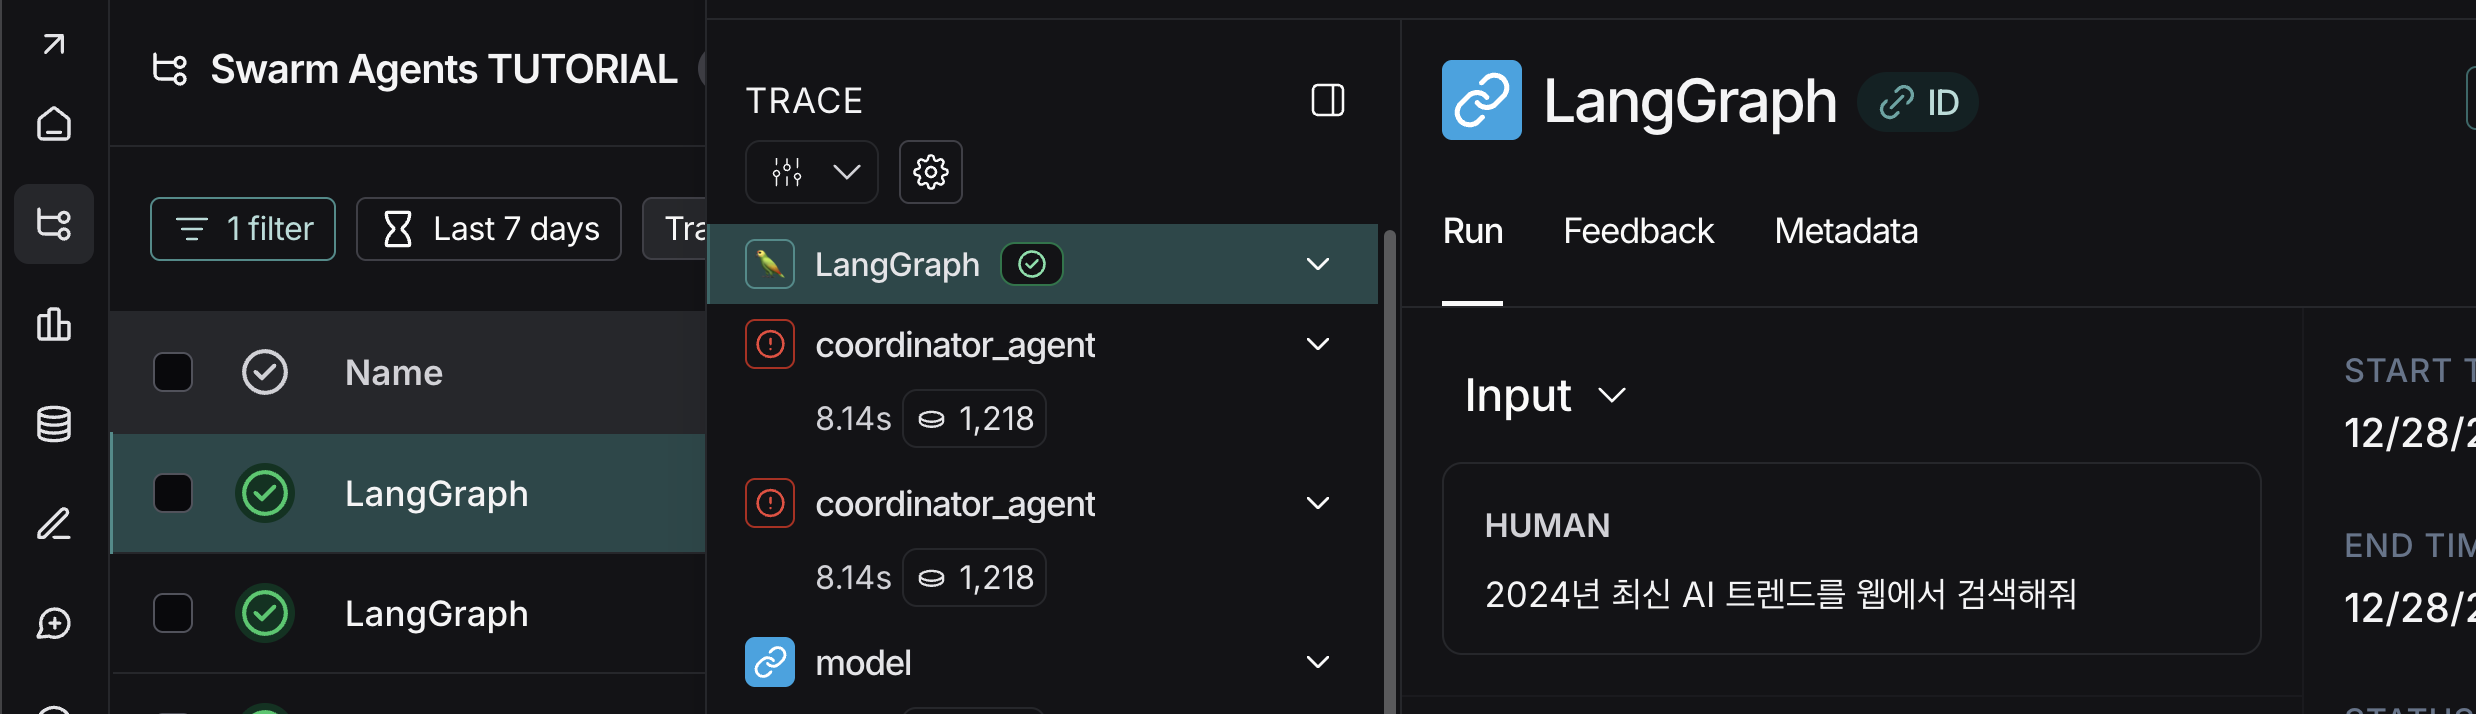